# Visual Style Clustering of Children's Book Covers

**Objective:** \
The present project implements and compares the results of two approaches whose process images and cluster the number of artistic styles used. The dataset used [Children and teen book covers](https://www.kaggle.com/datasets/thomaskonstantin/6000-children-and-teen-book-covers) from kaggle. The first approach is to train an Autoencoder model to get the main features from the covers and cluster them. The second approach gets the context vector and processes it agains the input using Latent Fusion and cluster the results. The objective is to compare which of the model defines better clusters.

# Model Application

## 1. Data Preprocessing.

Importing libraries section

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, mixed_precision, regularizers
from tensorflow.keras.models import Model
from tensorflow.keras.utils import plot_model
import gc
import json
import warnings
# from google.colab import drive
import multiprocessing

warnings.filterwarnings('ignore')

Initialize random seeds for reproducibility

In [2]:
tf.random.set_seed(42)
np.random.seed(42)

For after-training processes, local machine with CPU is used. This cell leverages the CPU cores using threading processing with almost all CPUs.

In [3]:
# Enable mixed precision for CPU optimization
mixed_precision.set_global_policy('mixed_float16')

# Get CPU count and set optimal thread configuration
n_cores = multiprocessing.cpu_count()
n_threads = max(n_cores - 1, 1)  # Leave one core free for system processes

# Configure TensorFlow for CPU optimization
tf.config.threading.set_inter_op_parallelism_threads(n_threads)
tf.config.threading.set_intra_op_parallelism_threads(n_threads)

# Optional: Set memory growth
physical_devices = tf.config.list_physical_devices('CPU')
try:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
except:
    pass

print(f"CPU Cores: {n_cores}")
print(f"Training threads: {n_threads}")

CPU Cores: 16
Training threads: 15


The model was trained using Google Colab environment using GPUs. This cell checks the GPU configuration.

In [4]:
# List all physical devices available to TensorFlow
gpus = tf.config.list_physical_devices('GPU')
print("Num GPUs Available: ", len(gpus))

# Set the devices names
device_cpu = '/cpu:0'
device_gpu = '/device:GPU:0'

Num GPUs Available:  0


To load the images, the drive is mounted in the project and the image path located.

In [6]:
# Load the source of the dataset from Google Drive
drive.mount('/content/drive')

# Project path.
wrk_dir = '/content/drive/MyDrive/Colab Notebooks/Fanshawe/3rdTerm/Deep_Learning_With_Tensorflow_Keras2/Project'
# Change the current working directory
os.chdir(wrk_dir)

Mounted at /content/drive


The ImagePreprocessor class prepares the images using OpenCV library. Image augmentation is not considered for this project. The methods implemented by the class are the following:
- preprocess_image: A classic pipeline is applied: reading in BGR, resizing, and normalizing.
- get_image_paths: Gets all the image paths to load and process them
- load_images_batch: Load the images using the paths in batches.

In [5]:
class ImagePreprocessor:
    """Handles image preprocessing using OpenCV with memory optimization"""

    def __init__(self, target_size=(224, 224)):
        self.target_size = target_size

    def preprocess_image(self, image_path):
        """Preprocess a single image"""
        try:
            # Read image
            img = cv2.imread(image_path)
            if img is None:
                return None

            # Convert BGR to RGB
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Resize image
            img = cv2.resize(img, self.target_size)

            # Normalize pixel values
            img = img.astype(np.float32) / 255.0

            return img
        except Exception as e:
            print(f"Error processing {image_path}: {e}")
            return None

    def get_image_paths(self, folder_path):
        """Get all valid image paths without loading images"""
        image_paths = []
        supported_formats = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')

        for filename in os.listdir(folder_path):
            if filename.lower().endswith(supported_formats):
                image_path = os.path.join(folder_path, filename)
                # Quick check if file can be read
                try:
                    test_img = cv2.imread(image_path)
                    if test_img is not None:
                        image_paths.append(image_path)
                    del test_img  # Free memory immediately
                except:
                    continue

        return image_paths

    def load_images_batch(self, image_paths, batch_size=100):
        """Load images in batches to avoid memory issues"""
        total_images = len(image_paths)

        for i in range(0, total_images, batch_size):
            batch_paths = image_paths[i:i + batch_size]
            batch_images = []

            for path in batch_paths:
                img = self.preprocess_image(path)
                if img is not None:
                    batch_images.append(img)

            if batch_images:
                yield np.array(batch_images), batch_paths[:len(batch_images)]

            # Force garbage collection
            gc.collect()

Two functions are defined to load the data:
- load_and_preprocess_data: Manages the loading, preprocessing, and splitting process of the data.
- _visualize_samples: Shows some samples before and after preprocessing.

In [6]:
def load_and_preprocess_data(folder_path, target_size=(224, 224), max_images=None, visualize=True):
    """Load, preprocess and split image data from given folder"""
    print("LOADING AND PREPROCESSING PHASE")
    print("=" * 40)

    # Initialize preprocessor
    preprocessor = ImagePreprocessor(target_size)

    print("Getting image paths...")
    # Get all valid image paths
    all_paths = preprocessor.get_image_paths(folder_path)

    # Limit number of images if specified
    if max_images and len(all_paths) > max_images:
        print(f"Limiting to {max_images} images from {len(all_paths)} available")
        all_paths = all_paths[:max_images]

    print(f"Found {len(all_paths)} valid images")

    # Split paths: 60% train, 20% val, 20% test
    temp_paths, test_paths = train_test_split(
        all_paths, test_size=0.2, random_state=42
    )

    train_paths, val_paths = train_test_split(
        temp_paths, test_size=0.25, random_state=42  # 0.25 of 0.8 = 0.2
    )

    print(f"Train set: {len(train_paths)} images")
    print(f"Validation set: {len(val_paths)} images")
    print(f"Test set: {len(test_paths)} images")

    # Visualize a few samples if requested
    if visualize and len(all_paths) > 0:
        _visualize_samples(preprocessor, all_paths)

    # Force garbage collection
    gc.collect()

    return {
        'all_paths': all_paths,
        'train_paths': train_paths,
        'val_paths': val_paths,
        'test_paths': test_paths,
        'n_images': len(all_paths),
        'n_train': len(train_paths),
        'n_val': len(val_paths),
        'n_test': len(test_paths)
    }

def _visualize_samples(preprocessor, image_paths, n_samples=3):
    """Visualize original vs preprocessed image samples"""
    print("Visualizing preprocessing results...")

    # Select random samples
    n_samples = min(n_samples, len(image_paths))
    sample_indices = np.random.choice(len(image_paths), n_samples, replace=False)

    fig, axes = plt.subplots(2, n_samples, figsize=(12, 6))
    if n_samples == 1:
        axes = axes.reshape(2, 1)

    for i, idx in enumerate(sample_indices):
        image_path = image_paths[idx]

        # Load and show original image
        original_img = cv2.imread(image_path)
        if original_img is not None:
            original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
            axes[0, i].imshow(original_img)
            axes[0, i].set_title(f'Original {i+1}')
            axes[0, i].axis('off')

            # Load and show preprocessed image
            processed_img = preprocessor.preprocess_image(image_path)
            if processed_img is not None:
                axes[1, i].imshow(processed_img)
                axes[1, i].set_title(f'Preprocessed {i+1}')
                axes[1, i].axis('off')

        # Free memory immediately
        del original_img
        if 'processed_img' in locals():
            del processed_img

    plt.suptitle('Original vs Preprocessed Images', fontsize=16)
    plt.tight_layout()
    plt.show()

    # Force garbage collection
    gc.collect()

Using the previous functions, the preprocessing is executed.

LOADING AND PREPROCESSING PHASE
Getting image paths...
Limiting to 5000 images from 6232 available
Found 5000 valid images
Train set: 3000 images
Validation set: 1000 images
Test set: 1000 images
Visualizing preprocessing results...


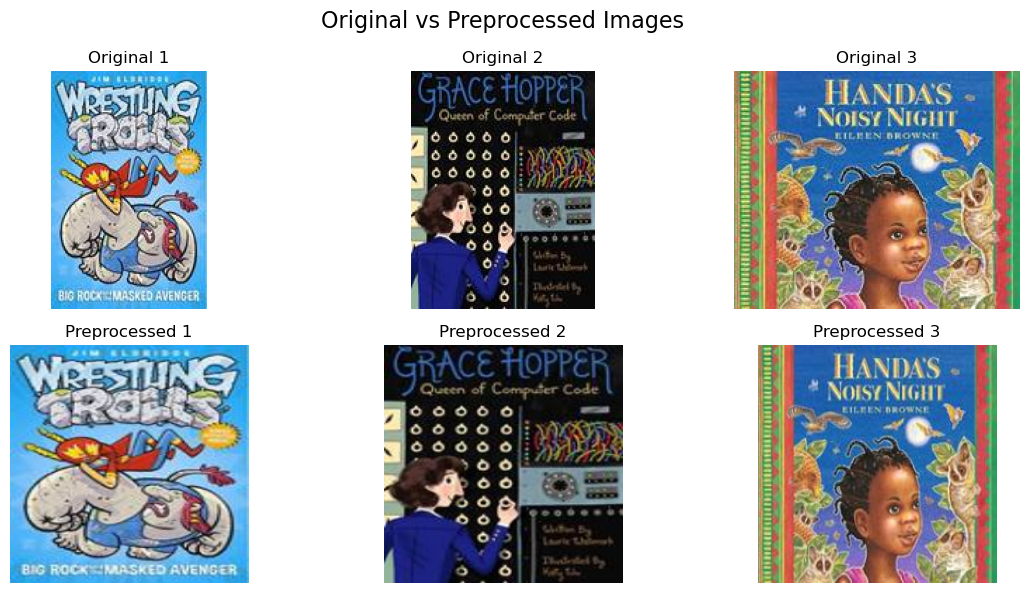

In [7]:
# Load and preprocess the data
data = load_and_preprocess_data(
    folder_path="book_covers",
    target_size=(224, 224),
    max_images=5000, # 5000
    visualize=True
)

# Access the split datasets
train_paths = data['train_paths']
val_paths = data['val_paths']
test_paths = data['test_paths']

## 2. Model Selection.

### Model 1 - Unsupervised Feature Learning with Autoencoder

The main idea is to discover patterns in the images without using any class from them. The next step, is to cluster these patterns and check how many of them are defined. An Autoencoder model with regularization, normalization and a simple attention mechanism is implemented to perform this task. These are the methods defined:
- build_model: four convolutional blocks, with regularizer and normalization, an attention mechanism before the average pooling, and a decoder with 3 blocks, with regularizer and normalization, is the architecture of the model. As a final layer, a linear layer is added to feed the clustering.
- compile_model: compiles the model using Adam optimizer and MSE as a loss function.
- create_feature_extractor: extracts features from the trained model
- train_autoencoder: creates and trains the model, returning the history as result.
- attention_block: builds the attention mechanism for the model

In [8]:
"""Model 1 - Unsupervised Feature Learning with Autoencoder"""
class CNNFeatureExtractor:
    """CNN model for feature extraction"""

    def __init__(self, input_shape=(224, 224, 3), l2_reg=0.001):
        self.input_shape = input_shape
        self.l2_reg = l2_reg
        self.model = None
        self.feature_extractor = None

    def attention_block(self, x):
        """Attention mechanism"""
        # Get the number of channels/filters
        channels = x.shape[-1]

        # Create a Sequential model for attention
        attention = layers.GlobalAveragePooling2D()(x)
        attention = layers.Reshape((1, 1, channels))(attention)
        attention = layers.Dense(
            channels,
            activation='sigmoid',
            kernel_initializer='he_normal',
            use_bias=False,
            kernel_regularizer=regularizers.l2(self.l2_reg)
        )(attention)

        # Apply attention
        return layers.multiply([x, attention])

    def build_model(self):
        """Build CNN model with attention"""
        inputs = layers.Input(shape=self.input_shape)

        # First convolutional block
        x = layers.Conv2D(32, (3, 3), activation='relu',
                         kernel_regularizer=regularizers.l2(self.l2_reg))(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D((2, 2))(x)

        # Second convolutional block
        x = layers.Conv2D(64, (3, 3), activation='relu',
                         kernel_regularizer=regularizers.l2(self.l2_reg))(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D((2, 2))(x)

        # Third convolutional block
        x = layers.Conv2D(128, (3, 3), activation='relu',
                         kernel_regularizer=regularizers.l2(self.l2_reg))(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D((2, 2))(x)

        # Fourth convolutional block
        x = layers.Conv2D(256, (3, 3), activation='relu',
                         kernel_regularizer=regularizers.l2(self.l2_reg))(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D((2, 2))(x)

        # Apply attention
        x = self.attention_block(x)

        # Global average pooling
        x = layers.GlobalAveragePooling2D()(x)

        # Dense layers with batch normalization
        x = layers.Dense(512, activation='relu',
                        kernel_regularizer=regularizers.l2(self.l2_reg))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.5)(x)

        x = layers.Dense(256, activation='relu',
                        kernel_regularizer=regularizers.l2(self.l2_reg))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.3)(x)

        x = layers.Dense(128, activation='relu',
                        kernel_regularizer=regularizers.l2(self.l2_reg),
                        name='feature_layer')(x)
        x = layers.BatchNormalization()(x)

        outputs = layers.Dense(64, activation='linear', dtype='float32')(x)

        # Create model
        self.model = keras.Model(inputs, outputs)
        return self.model

    def compile_model(self, learning_rate=0.0005):
        """Compile the model"""
        optimizer = keras.optimizers.Adam(
            learning_rate=learning_rate,
            beta_1=0.9,
            beta_2=0.999,
            amsgrad=True  # Enable AMSGrad variant
        )

        # Using MSE loss
        self.model.compile(
            optimizer=optimizer,
            loss='mse',
            metrics=['mae']
        )

    def create_feature_extractor(self):
        """Create feature extractor from trained model"""
        if self.model is None:
            raise ValueError("Model must be built first")

        # Define the output layer for the feature extractor
        feature_layer = self.model.get_layer(name='feature_layer')

        # Create the feature extractor model using the model's input and the feature layer's output
        self.feature_extractor = keras.Model(
            inputs=self.model.input,
            outputs=feature_layer.output
        )
        return self.feature_extractor

    def train_autoencoder(self, X_train, X_val, epochs=50, batch_size=32):
        """Train model as an autoencoder for unsupervised feature learning"""
        # Create autoencoder architecture
        encoder = self.model

        # Decoder - with regularization and batch normalization
        decoder_input = keras.Input(shape=(64,))
        x = layers.Dense(128, activation='relu',
                         kernel_regularizer=regularizers.l2(self.l2_reg))(decoder_input)
        x = layers.BatchNormalization()(x)

        x = layers.Dense(256, activation='relu',
                         kernel_regularizer=regularizers.l2(self.l2_reg))(x)
        x = layers.BatchNormalization()(x)

        x = layers.Dense(512, activation='relu',
                         kernel_regularizer=regularizers.l2(self.l2_reg))(x)
        x = layers.BatchNormalization()(x)

        x = layers.Dense(14*14*256, activation='relu',
                         kernel_regularizer=regularizers.l2(self.l2_reg))(x)
        x = layers.BatchNormalization()(x)

        x = layers.Reshape((14, 14, 256))(x)

        # Add attention mechanism
        attention = layers.GlobalAveragePooling2D()(x)
        attention = layers.Dense(256, activation='sigmoid')(attention)
        x = layers.Multiply()([x, attention])

        x = layers.Conv2DTranspose(128, (3, 3), activation='relu', padding='same',
                                   kernel_regularizer=regularizers.l2(0.01))(x)
        x = layers.BatchNormalization()(x)
        x = layers.UpSampling2D((2, 2))(x)

        x = layers.Conv2DTranspose(64, (3, 3), activation='relu', padding='same',
                                   kernel_regularizer=regularizers.l2(0.01))(x)
        x = layers.BatchNormalization()(x)
        x = layers.UpSampling2D((2, 2))(x)

        x = layers.Conv2DTranspose(32, (3, 3), activation='relu', padding='same',
                                   kernel_regularizer=regularizers.l2(0.01))(x)
        x = layers.BatchNormalization()(x)
        x = layers.UpSampling2D((2, 2))(x)

        x = layers.Conv2DTranspose(3, (3, 3), activation='sigmoid', padding='same')(x)
        x = layers.UpSampling2D((2, 2))(x)

        decoder = keras.Model(decoder_input, x)

        # Combined autoencoder
        autoencoder_input = keras.Input(shape=self.input_shape)
        encoded = encoder(autoencoder_input)
        decoded = decoder(encoded)
        autoencoder = keras.Model(autoencoder_input, decoded)

        # Use modified optimizer
        optimizer = keras.optimizers.Adam(
            learning_rate=0.0005,
            beta_1=0.9,
            beta_2=0.999,
            amsgrad=True
        )

        autoencoder.compile(optimizer=optimizer, loss='mse')

        # Train autoencoder
        history = autoencoder.fit(
            X_train, X_train,
            validation_data=(X_val, X_val),
            epochs=epochs,
            batch_size=batch_size,
            verbose=1
        )

        return history

### Model 2 - Image + Latent Fusion for Clustering

In this approach, the latent context vector is extracted from a trained autoencoder. Then, combine this context with the original image features to form enriched representations. These representations are used as inputs for K-Means++ clustering. These are the methods of the class:
- extract_latent_vectors: gets the latent vector from the autoencoder.
- flatten_images: flatten images to build the input.
- fuse_features: fuse features combining low-level features (after PCA) and high-level latent vectors from the autoencoder.

In [9]:
class CNNLatentFusion:
    """Fuses CNN latent vectors with original image features"""

    def __init__(self, trained_cnn_model, input_shape=(224, 224, 3)):
        self.cnn_model = trained_cnn_model
        self.input_shape = input_shape
        self.scaler = StandardScaler()
        self.fused_features = None
        self.preprocessor = ImagePreprocessor(input_shape[:2])

    def extract_latent_vectors(self, images):
        """Extract latent vectors using trained encoder"""
        if self.cnn_model.feature_extractor is None:
            raise ValueError("CNN model feature extractor not initialized")
        return self.cnn_model.feature_extractor.predict(images, verbose=0)

    def flatten_images(self, images):
        """Get raw pixel features from images"""
        return images.reshape(images.shape[0], -1)

    def fuse_features(self, images, batch_size=128, pca_components=50):
        """
        Fuse image features with latent vectors with dimensionality reduction
        Args:
            images: Image paths or array
            batch_size: Size of batches to process
            pca_components: Number of PCA components
        """
        print("Performing feature fusion...")
        all_image_features = []
        all_latent_vectors = []

        # First pass: collect all features
        for batch_images, _ in self.preprocessor.load_images_batch(images, batch_size):
            # Get latent vectors
            latent_vectors = self.extract_latent_vectors(batch_images)

            # Get image features
            image_features = self.flatten_images(batch_images)

            # Store features
            all_image_features.append(image_features)
            all_latent_vectors.append(latent_vectors)

            # Clean up batch data
            del latent_vectors, image_features
            gc.collect()

        # Combine all features
        all_image_features = np.vstack(all_image_features)
        all_latent_vectors = np.vstack(all_latent_vectors)

        # Now apply PCA on complete image features
        from sklearn.decomposition import PCA
        n_samples = all_image_features.shape[0]
        pca_components = min(pca_components, n_samples - 1)
        print(f"Applying PCA with {pca_components} components on {n_samples} samples")

        pca = PCA(n_components=pca_components)
        image_features_reduced = pca.fit_transform(all_image_features)

        # Concatenate reduced features with latent vectors
        self.fused_features = np.concatenate([image_features_reduced, all_latent_vectors], axis=1)
        self.fused_features = self.scaler.fit_transform(self.fused_features)

        # Clean up
        del all_image_features, all_latent_vectors, image_features_reduced
        gc.collect()

        print(f"Feature fusion complete. Shape: {self.fused_features.shape}")
        return self.fused_features

## 3. Training Process.

### Model 1 - Unsupervised Feature Learning with Autoencoders

The following 4 methods were created to manage the training process of the autoencoder:
- create_data_generator: Generates the data for training process in a CPU friendly process.
- build_autoencoder: Builds the autoencoder using the class defined before.
- train_model: Manages the training process and saves the weights and history of the model.
- save_weights: Saves the weights and history of the trained model.

In [10]:
def create_data_generator(preprocessor, image_paths, target_size=(224, 224), batch_size=32):
    """Create a data generator for memory-efficient training"""
    def generator():
        while True:
            # Shuffle paths each epoch
            shuffled_paths = np.random.permutation(image_paths)

            for i in range(0, len(shuffled_paths), batch_size):
                batch_paths = shuffled_paths[i:i + batch_size]
                batch_images = []

                for path in batch_paths:
                    img = preprocessor.preprocess_image(path)
                    if img is not None:
                        batch_images.append(img)

                if batch_images:
                    batch_array = np.array(batch_images)
                    yield batch_array, batch_array  # For autoencoder training

                    # Clean up
                    del batch_images, batch_array
                    gc.collect()

    return generator

def build_autoencoder(cnn_model, target_size=(224, 224), l2_reg=0.001):
    """Build autoencoder using CNN model as encoder"""
    # Encoder (use the CNN model)
    encoder = cnn_model

    # Decoder
    decoder_input = keras.Input(shape=(64,))
    x = layers.Dense(128, activation='relu',
                    kernel_regularizer=regularizers.l2(l2_reg))(decoder_input)
    x = layers.BatchNormalization()(x)

    x = layers.Dense(256, activation='relu',
                    kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)

    x = layers.Dense(512, activation='relu',
                    kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)

    x = layers.Dense(14*14*256, activation='relu',
                    kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Reshape((14, 14, 256))(x)

    # Add attention mechanism
    attention = layers.GlobalAveragePooling2D()(x)
    attention = layers.Dense(256, activation='sigmoid')(attention)
    x = layers.Multiply()([x, attention])

    x = layers.Conv2DTranspose(128, (3, 3), activation='relu', padding='same',
                             kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.UpSampling2D((2, 2))(x)

    x = layers.Conv2DTranspose(64, (3, 3), activation='relu', padding='same',
                             kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.UpSampling2D((2, 2))(x)

    x = layers.Conv2DTranspose(32, (3, 3), activation='relu', padding='same',
                             kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.UpSampling2D((2, 2))(x)

    x = layers.Conv2DTranspose(3, (3, 3), activation='sigmoid', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)

    decoder = keras.Model(decoder_input, x)

    # Combined autoencoder
    autoencoder_input = keras.Input(shape=(*target_size, 3))
    encoded = encoder(autoencoder_input)
    decoded = decoder(encoded)
    autoencoder = keras.Model(autoencoder_input, decoded)

    # Use modified optimizer
    optimizer = keras.optimizers.Adam(
        learning_rate=0.0005,
        beta_1=0.9,
        beta_2=0.999,
        amsgrad=True
    )

    autoencoder.compile(optimizer=optimizer, loss='mse')

    return autoencoder

def train_model(cnn_extractor, train_paths, val_paths, target_size=(224, 224),
                epochs=30, batch_size=16, weights_folder="model_weights"):
    """Train CNN feature extractor using autoencoders"""
    print("\nTRAINING PHASE")
    print("=" * 30)

    # Initialize preprocessor
    preprocessor = ImagePreprocessor(target_size)

    print("Building and training CNN feature extractor...")

    # Build and compile model
    cnn_extractor.build_model()
    cnn_extractor.compile_model()

    # Create data generators
    train_generator = create_data_generator(preprocessor, train_paths, target_size, batch_size)
    val_generator = create_data_generator(preprocessor, val_paths, target_size, batch_size)

    # Calculate steps per epoch
    steps_per_epoch = len(train_paths) // batch_size
    validation_steps = len(val_paths) // batch_size

    print(f"Training with {steps_per_epoch} steps per epoch, {validation_steps} validation steps")

    # Create datasets from generators
    train_dataset = tf.data.Dataset.from_generator(
        train_generator,
        output_signature=(
            tf.TensorSpec(shape=(None, *target_size, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(None, *target_size, 3), dtype=tf.float32)
        )
    )

    val_dataset = tf.data.Dataset.from_generator(
        val_generator,
        output_signature=(
            tf.TensorSpec(shape=(None, *target_size, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(None, *target_size, 3), dtype=tf.float32)
        )
    )

    # Build and train autoencoder
    autoencoder = build_autoencoder(cnn_extractor.model, target_size)

    history = autoencoder.fit(
        train_dataset,
        steps_per_epoch=steps_per_epoch,
        epochs=epochs,
        validation_data=val_dataset,
        validation_steps=validation_steps,
        verbose=1
    )

    # # Create feature extractor
    # cnn_extractor.create_feature_extractor()

    # # Save model weights and history
    # if weights_folder:
    #     save_weights(cnn_extractor=cnn_extractor,
    #                 history=history,
    #                 weights_folder=weights_folder)  # Use keyword arguments

    print("Training phase completed!")

    # Clean up
    del train_dataset, val_dataset
    gc.collect()

    return history

def save_weights(cnn_extractor, history, weights_folder="model_weights"):
    """Save model weights and training history to files"""
    print("Saving model weights and history...")

    # Create weights folder if it doesn't exist
    os.makedirs(weights_folder, exist_ok=True)

    # Save main model weights
    main_model_path = os.path.join(weights_folder, "main_model_weights.weights.h5")
    cnn_extractor.model.save_weights(main_model_path)

    # Save model architecture as JSON
    model_config_path = os.path.join(weights_folder, "model_config.json")
    with open(model_config_path, 'w') as f:
        f.write(cnn_extractor.model.to_json())

    # Save training history as JSON
    history_path = os.path.join(weights_folder, "training_history.json")
    history_dict = {
        'loss': [float(x) for x in history.history['loss']],
        'val_loss': [float(x) for x in history.history['val_loss']]
    }
    with open(history_path, 'w') as f:
        json.dump(history_dict, f)

    print(f"Model weights and history saved to {weights_folder}/")

Using the previous functions, the model is trained and the weights saved.

In [14]:
# Initialize CNN Feature Extractor
cnn_extractor = CNNFeatureExtractor(input_shape=(224, 224, 3))

# Train the model
history = train_model(
    cnn_extractor=cnn_extractor,
    train_paths=train_paths,
    val_paths=val_paths,
    target_size=(224, 224),
    epochs=20, #20
    batch_size=16,
    weights_folder="model_weights"
)


TRAINING PHASE
Building and training CNN feature extractor...
Training with 187 steps per epoch, 62 validation steps
Epoch 1/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 137s 518ms/step - loss: 3.4164 - val_loss: 0.7239
Epoch 2/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 114s 502ms/step - loss: 0.5244 - val_loss: 0.2431
Epoch 3/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 141s 754ms/step - loss: 0.1788 - val_loss: 0.1407
Epoch 4/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 142s 760ms/step - loss: 0.1075 - val_loss: 0.1034
Epoch 5/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 97s 518ms/step - loss: 0.0894 - val_loss: 0.0938
Epoch 6/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 131s 705ms/step - loss: 0.0856 - val_loss: 0.0948
Epoch 7/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 90s 480ms/step - loss: 0.0845 - val_loss: 0.0842
Epoch 8/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 89s 475ms/step - loss: 0.0841 - val_loss: 0.0945
Epoch 9/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 88s 473ms/step - loss: 0.0821 - val_loss: 0.0918
Epoch 10/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 122s 654ms/step - loss: 0.0831 - va

TypeError: too many positional arguments

### Optional model 1 - Save model function

In case that the training process was a success but an error raises from the next steps, a function to save the weights of the trained model is defined to perform this process. This function only saves the weights of the model

In [11]:
def save_model_weights(cnn_extractor, weights_folder="model_weights"):
    """Save model weights to files"""
    print("Saving model weights...")

    # Create weights folder if it doesn't exist
    os.makedirs(weights_folder, exist_ok=True)

    # Save main model weights
    main_model_path = os.path.join(weights_folder, "main_model_weights.weights.h5")
    cnn_extractor.model.save_weights(main_model_path)

    # Save model architecture as JSON
    model_config_path = os.path.join(weights_folder, "model_config.json")
    with open(model_config_path, 'w') as f:
        f.write(cnn_extractor.model.to_json())

    print(f"Model weights saved to {weights_folder}/")

In [ ]:
save_model_weights(cnn_extractor, "model_weights")

Saving model weights...
Model weights saved to model_weights/


### Optional model 1 - Model loading

The following code loads the model to evaluate it  in the same Google Colab (CPU or GPU) environment or in local. These are the methods:
- load_trained_model: loads the weights of the model in a new class.
- extract_features: extracts the features from the loaded model.
- load_training_history: loads the saved history of the trained model.

In [10]:
def load_trained_model(cnn_extractor, weights_folder="model_weights"):
    """Load pre-trained model weights"""
    print("Loading pre-trained model...")

    # Check if weights exist
    main_model_path = os.path.join(weights_folder, "main_model_weights.weights.h5")
    model_config_path = os.path.join(weights_folder, "model_config.json")

    if not all(os.path.exists(path) for path in [main_model_path, model_config_path]):
        raise FileNotFoundError(f"Model weights not found in {weights_folder}/. Train the model first.")

    # Build model architecture first
    cnn_extractor.build_model()

    # Compile the model (this helps with graph initialization)
    cnn_extractor.compile_model()

    # Build the model properly by calling it with dummy data BEFORE loading weights
    dummy_input = tf.zeros((1, *cnn_extractor.input_shape))
    _ = cnn_extractor.model(dummy_input)

    # Now load the weights after the model has been properly built
    cnn_extractor.model.load_weights(main_model_path)

    # Create feature extractor - now the model should have proper input/output tensors
    cnn_extractor.create_feature_extractor()

    print("Pre-trained model loaded successfully!")
    return True

def extract_features(cnn_extractor, preprocessor, image_paths, batch_size=32):
    """Extract features from all images using batches"""
    print("Extracting features from images...")

    if cnn_extractor.feature_extractor is None:
        raise ValueError("Feature extractor not initialized. Load or train the model first.")

    all_features = []

    # Process images in batches
    for batch_images, batch_paths in preprocessor.load_images_batch(
        image_paths, batch_size=batch_size
    ):
        # Extract features for this batch
        batch_features = cnn_extractor.feature_extractor.predict(
            batch_images, verbose=0
        )
        all_features.append(batch_features)

        # Clean up
        del batch_images, batch_features
        gc.collect()

    # Concatenate all features
    features = np.vstack(all_features)
    print(f"Features extracted. Shape: {features.shape}")

    # Clean up
    del all_features
    gc.collect()

    return features

def load_training_history(weights_folder="model_weights"):
    """Load training history from file"""
    history_path = os.path.join(weights_folder, "training_history.json")

    if not os.path.exists(history_path):
        raise FileNotFoundError(f"Training history not found in {weights_folder}/")

    with open(history_path, 'r') as f:
        history_dict = json.load(f)

    # Create a simple object to mimic keras history
    class History:
        pass
    history = History()
    history.history = history_dict

    return history

Using the previous functions, the model is loaded from weights. First, the necessary objects are created and the images are loaded. Then, it is time to load the weights of the model and the history.

In [11]:
# Initialize components
preprocessor = ImagePreprocessor(target_size=(224, 224))
cnn_extractor = CNNFeatureExtractor(input_shape=(224, 224, 3))

In [12]:
print("Model objects created\n")

# Load and preprocess data
data = load_and_preprocess_data(
    folder_path="book_covers",
    target_size=(224, 224),
    max_images=5000,
    visualize=False
)

print(f"Loaded {data['n_images']} images")
print("Data loaded and preprocessed\n")

Model objects created

LOADING AND PREPROCESSING PHASE
Getting image paths...
Limiting to 5000 images from 6232 available
Found 5000 valid images
Train set: 3000 images
Validation set: 1000 images
Test set: 1000 images
Loaded 5000 images
Data loaded and preprocessed



In [13]:
print("Initializing loading model process")

# Load pre-trained model weights and history
load_trained_model(cnn_extractor, weights_folder="model_weights")
history = load_training_history(weights_folder="model_weights")

print("Model weights and history loaded\n")

# Extract features using pre-trained model
features = extract_features(
    cnn_extractor=cnn_extractor,
    preprocessor=preprocessor,
    image_paths=data['all_paths']
)

print("Features extracted\n")

Initializing loading model process
Loading pre-trained model...
Pre-trained model loaded successfully!
Model weights and history loaded

Extracting features from images...
Features extracted. Shape: (5000, 128)
Features extracted



### Optional model 1 - Save the history and generating feature extractor

Following the previous logic, a function to save the history of the model is created. If the history object is still available and has data, it is saved. Otherwise, the data from the history of the model must be gotten manually of the output of the training process. To complete the process, the feature extractor is generated from the model.

In [27]:
# Function to save training history
def save_history(history, weights_folder="model_weights"):
    """Save training history to files"""
    print("Saving training history...")

    # Save training history as JSON
    history_path = os.path.join(weights_folder, "training_history.json")
    history_dict = {
        'loss': [float(x) for x in history['loss']],
        'val_loss': [float(x) for x in history['val_loss']]
    }
    with open(history_path, 'w') as f:
        json.dump(history_dict, f)

    print(f"Training history saved to {weights_folder}/")

In [ ]:
# Check if history exists
if history is None or not hasattr(history, 'history'):
    print("No training history found. Saving history from output.")
    # Data from output of training cell
    history = {
        'loss': [3.4164, 0.5244, 0.1788, 0.1075, 0.0894, 0.0856, 0.0845, 0.0841, 0.0821, 0.0831, 0.0820, 0.0836, 0.0825, 0.0807, 0.0824, 0.0818, 0.0813, 0.0809, 0.0835, 0.0807],
        'val_loss': [0.7239, 0.2431, 0.1407, 0.1034, 0.0938, 0.0948, 0.0842, 0.0945, 0.0918, 0.0860, 0.1083, 0.0913, 0.0833, 0.0880, 0.0825, 0.0963, 0.0883, 0.0915, 0.0883, 0.0916]
    }

save_history(history, weights_folder="model_weights")

Saving training history...
Training history saved to model_weights/


In [34]:
def create_feature_extractor_from_model(model, input_shape=(224, 224, 3)):
    """
    Create a feature extractor from a trained model

    Args:
        model: The trained Keras model
        input_shape: Input shape of the model (default: (224, 224, 3))

    Returns:
        feature_extractor: A new Keras model that outputs features from the feature layer
    """
    if model is None:
        raise ValueError("Model must be provided")

    try:
        print("Creating feature extractor from model...")

        # Define the output layer for the feature extractor
        feature_layer = model.get_layer(name='feature_layer')

        # Create the feature extractor model using the model's input and the feature layer's output
        feature_extractor = keras.Model(
            inputs=model.input,
            outputs=feature_layer.output
        )

        print("Feature extractor created successfully!")

        return feature_extractor

    except ValueError as e:
        print(f"Error: Could not find 'feature_layer' in model. {str(e)}")
        return None
    except Exception as e:
        print(f"Error creating feature extractor: {str(e)}")
        return None

In [35]:
# Create feature extractor
feature_extractor = create_feature_extractor_from_model(
    model=cnn_extractor.model,
    input_shape=(224, 224, 3)
)

save_model_weights(cnn_extractor, "model_weights")

Creating feature extractor from model...
Feature extractor created successfully!
Saving model weights...
Model weights saved to model_weights/


### Model 2 - Image + Latent Fusion for Clustering

The fusion model is created in the following cell. Begore execute it, the base model must be trained or loaded.

In [14]:
print("Initializing fusion model process...")

# Initialize CNN Latent Fusion
fusion_model = CNNLatentFusion(cnn_extractor, input_shape=(224, 224, 3))

# Get fused features (combined raw image features + latent vectors)
fused_features = fusion_model.fuse_features(data['all_paths'], batch_size=32)

Initializing fusion model process...
Performing feature fusion...
Applying PCA with 50 components on 5000 samples
Feature fusion complete. Shape: (5000, 178)


## 4. Evaluation.

### Base process definition

Getting the best number of clusters in K-Means is a tough task. The following method calculates the best number of clusters using the Elbow Method in a specific range. The process uses K-Means++ as default, but regular K-means can be used via parameter. At the end, the process gets the point with the maximum curvature as the best k.
TO evaluate the model, three metrics are used:
- **Silhouette score:** Score ranges are between -1 to +1, with higher values indicating better-defined clusters.
- **Davies-Bouldin Index:** Evaluate the quality of clustering algorithms. Consider both intra-cluster similarity (compactness) and inter-cluster difference (separation). Lower values indicate better clustering quality.
- **Calinski-Harabasz Index:** It balances the compactness and separation of clusters. In other words, it indicates how well the data points are grouped into distinct clusters. Higher values indicate better balance.

In [ ]:
class ClusteringAnalyzer:
    """Handle clustering analysis and evaluation for CNN features"""

    def __init__(self, cnn_extractor=None):
        self.scaler = StandardScaler()
        self.kmeans_model = None
        self.optimal_k = None
        self.cnn_extractor = cnn_extractor
        self.features = None
        self.features_scaled = None
        self.cluster_labels = None

    def set_cnn_extractor(self, cnn_extractor):
        """Set CNN feature extractor after initialization"""
        self.cnn_extractor = cnn_extractor

    def process_features(self, features):
        """Process and store features"""
        self.features = features
        self.features_scaled = self.scaler.fit_transform(features)
        return self.features_scaled

    def elbow_method(self, k_range=range(2, 21), plot=True):
        """Find optimal number of clusters using elbow method"""
        if self.features_scaled is None:
            raise ValueError("No features available. Process features first.")

        inertias = []

        print("CLUSTERING PHASE")
        print("==============================")
        print("Finding optimal number of clusters...")

        for k in k_range:
            kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
            kmeans.fit(self.features_scaled)
            inertias.append(kmeans.inertia_)

        if plot:
            plt.figure(figsize=(10, 6))
            plt.plot(k_range, inertias, 'bo-')
            plt.xlabel('Number of Clusters (k)')
            plt.ylabel('Inertia')
            plt.title('Elbow Method for Optimal k')
            plt.grid(True)
            plt.show()

        # Find the point with maximum curvature
        diffs = np.diff(inertias)
        diffs2 = np.diff(diffs)
        elbow_idx = np.argmax(diffs2) + 2
        self.optimal_k = k_range[elbow_idx]

        return k_range, inertias, self.optimal_k

    def perform_clustering(self, n_clusters=None, use_kmeans_plus=True, sample_size=None):
        """Perform clustering with optional data sampling"""
        if self.features_scaled is None:
            raise ValueError("No features available. Process features first.")

        if n_clusters is None:
            n_clusters = self.optimal_k if self.optimal_k else 8

        # Sample data if specified
        if sample_size and sample_size < len(self.features_scaled):
            from sklearn.utils import resample
            features_sampled = resample(self.features_scaled,
                                    n_samples=sample_size,
                                    random_state=42)
        else:
            features_sampled = self.features_scaled

        # Use mini-batch KMeans for large datasets
        if len(features_sampled) > 10000:
            from sklearn.cluster import MiniBatchKMeans
            self.kmeans_model = MiniBatchKMeans(
                n_clusters=n_clusters,
                init='k-means++' if use_kmeans_plus else 'random',
                random_state=42,
                batch_size=1024,
                max_iter=100
            )
        else:
            self.kmeans_model = KMeans(
                n_clusters=n_clusters,
                init='k-means++' if use_kmeans_plus else 'random',
                random_state=42,
                n_init=10
            )

        self.cluster_labels = self.kmeans_model.fit_predict(features_sampled)
        return self.cluster_labels

    def evaluate_clustering(self):
        """Evaluate clustering performance"""
        if self.features_scaled is None or self.cluster_labels is None:
            raise ValueError("Clustering not performed yet")

        # Calculate metrics
        metrics = {
            'silhouette_score': silhouette_score(
                self.features_scaled,
                self.cluster_labels
            ),
            'davies_bouldin_index': davies_bouldin_score(
                self.features_scaled,
                self.cluster_labels
            ),
            'calinski_harabasz_index': calinski_harabasz_score(
                self.features_scaled,
                self.cluster_labels
            )
        }

        # Print results
        print("\nClustering Evaluation Metrics:")
        print(f"Silhouette Score: {metrics['silhouette_score']:.4f}")
        print(f"Davies-Bouldin Index: {metrics['davies_bouldin_index']:.4f}")
        print(f"Calinski-Harabasz Index: {metrics['calinski_harabasz_index']:.4f}")

        return metrics

    def evaluation_phase(self, plot_distribution=True):
        """Complete evaluation phase: calculate metrics and visualize results"""
        print("\nEVALUATION PHASE")
        print("=" * 30)

        if self.features_scaled is None or self.cluster_labels is None:
            raise ValueError("Clustering not performed. Run process_features() and perform_clustering() first.")

        # Calculate evaluation metrics
        print("Calculating evaluation metrics...")
        metrics = self.evaluate_clustering()

        # Get cluster summary data
        cluster_summary = {
            'n_clusters': len(np.unique(self.cluster_labels)),
            'cluster_sizes': dict(zip(*np.unique(self.cluster_labels, return_counts=True)))
        }

        # Print summary
        print("\nClustering Summary:")
        print(f"Number of clusters: {cluster_summary['n_clusters']}")
        print("\nCluster sizes:")
        for cluster, size in cluster_summary['cluster_sizes'].items():
            print(f"Cluster {cluster}: {size} images")

        # Visualize cluster distribution
        if plot_distribution:
            plt.figure(figsize=(12, 5))

            # Plot 1: Cluster distribution
            plt.subplot(1, 2, 1)
            unique_clusters, counts = np.unique(self.cluster_labels, return_counts=True)
            plt.bar(unique_clusters, counts, color='skyblue', alpha=0.7)
            plt.xlabel('Cluster')
            plt.ylabel('Number of Images')
            plt.title('Distribution of Images Across Clusters')
            plt.grid(True, alpha=0.3)

            # Plot 2: Cluster sizes as pie chart
            plt.subplot(1, 2, 2)
            plt.pie(counts, labels=[f'Cluster {i}' for i in unique_clusters],
                autopct='%1.1f%%', startangle=90)
            plt.title('Cluster Size Distribution')

            plt.tight_layout()
            plt.show()

        evaluation_results = {
            'evaluation_results': metrics,
            'cluster_summary': cluster_summary
        }

        return evaluation_results

    # Add this method to ClusteringAnalyzer class
    def visualize_clusters_tsne(self, perplexity=30, sample_size=None):
        """
        Visualize clusters using t-SNE dimensionality reduction
        Args:
            perplexity: t-SNE perplexity parameter (default=30)
            sample_size: Number of samples to use (default=None, use all data)
        """
        if self.features_scaled is None or self.cluster_labels is None:
            raise ValueError("Clustering not performed yet. Run process_features() and perform_clustering() first.")

        # Sample data if specified
        if sample_size and sample_size < len(self.features_scaled):
            from sklearn.utils import resample
            features_sampled, labels_sampled = resample(
                self.features_scaled,
                self.cluster_labels,
                n_samples=sample_size,
                random_state=42,
                stratify=self.cluster_labels
            )
        else:
            features_sampled = self.features_scaled
            labels_sampled = self.cluster_labels

        print("Performing t-SNE dimensionality reduction...")
        tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42)
        features_2d = tsne.fit_transform(features_sampled)

        # Create DataFrame for easier plotting
        df = pd.DataFrame({
            'x': features_2d[:, 0],
            'y': features_2d[:, 1],
            'cluster': labels_sampled
        })

        # Plot
        plt.figure(figsize=(12, 8))

        # Scatter plot with custom styling
        sns.scatterplot(
            data=df,
            x='x',
            y='y',
            hue='cluster',
            palette='deep',
            alpha=0.6,
            s=100
        )

        plt.title('Cluster Visualization using t-SNE', fontsize=14, pad=20)
        plt.xlabel('t-SNE Component 1', fontsize=12)
        plt.ylabel('t-SNE Component 2', fontsize=12)

        # Add cluster centers if available
        if self.kmeans_model is not None:
            try:
                centers_2d = tsne.fit_transform(self.kmeans_model.cluster_centers_)
                plt.scatter(
                    centers_2d[:, 0],
                    centers_2d[:, 1],
                    c='red',
                    marker='x',
                    s=200,
                    linewidths=3,
                    label='Cluster Centers'
                )
            except:
                print("Note: Could not plot cluster centers in t-SNE space")

        # Adjust legend
        plt.legend(
            title='Clusters',
            bbox_to_anchor=(1.05, 1),
            loc='upper left',
            borderaxespad=0.
        )

        plt.tight_layout()
        plt.show()

        # Clean up
        plt.close()
        del df
        gc.collect()

        return features_2d  # Return the t-SNE coordinates for further analysis if needed

A second function to plot the training history is also created. The objective is to check if the model converge over time.

In [16]:
def plot_training_history(history):
    """Plot training and validation loss over epochs"""
    plt.figure(figsize=(10, 6))

    # Check if history is a Keras History object or a dictionary
    if hasattr(history, 'history'):
        history_dict = history.history
    else:
        history_dict = history

    plt.plot(history_dict['loss'], label='Training Loss')
    plt.plot(history_dict['val_loss'], label='Validation Loss')
    plt.title('Model Training Convergence')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

### Model 1 - Unsupervised Feature Learning with Autoencoders

The following code exports to an image the architecture of the model. It is not crucial for the model's functionality but helps in understanding the model structure and evaluation.

In [ ]:
plot_model(cnn_extractor.model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)

The model is evaluated with two approaches: a visual using the model loss from training and validation, and a numerical using the previously defined in the class. The next cell shows the visual convergence of training vs validation.

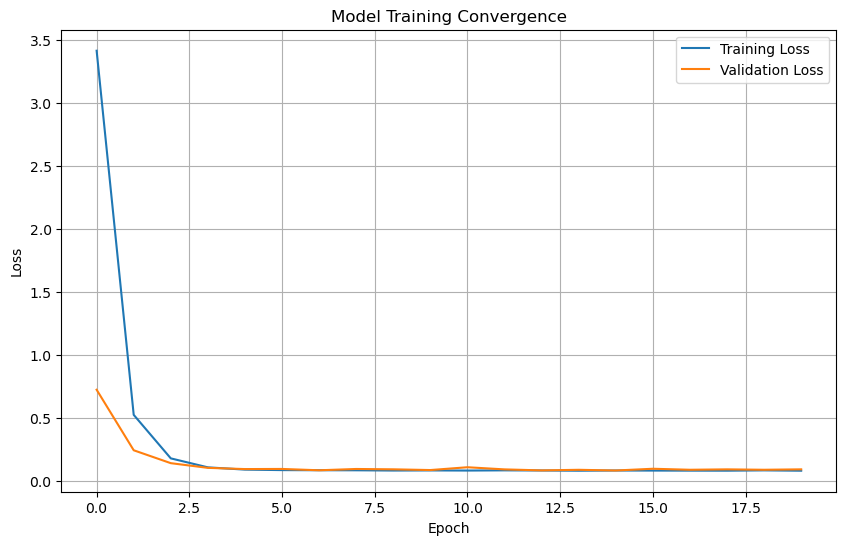

In [17]:
plot_training_history(history)

The plot from the elbow method is shown and then the clustering is executed using the optimzal number of clusters.

CLUSTERING PHASE
Finding optimal number of clusters...


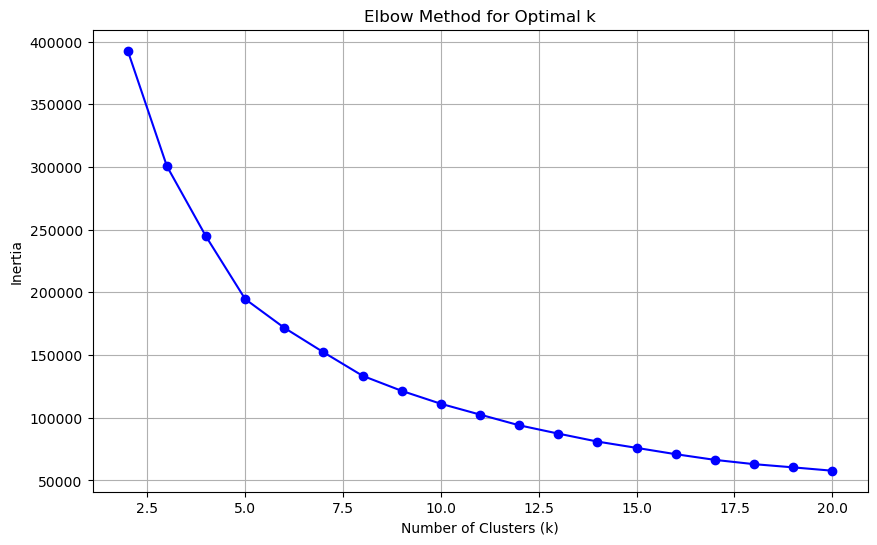


Optimal number of clusters: 4

EVALUATION PHASE
Calculating evaluation metrics...

Clustering Evaluation Metrics:
Silhouette Score: 0.4131
Davies-Bouldin Index: 0.9473
Calinski-Harabasz Index: nan

Clustering Summary:
Number of clusters: 4

Cluster sizes:
Cluster 0: 532 images
Cluster 1: 2816 images
Cluster 2: 1365 images
Cluster 3: 287 images


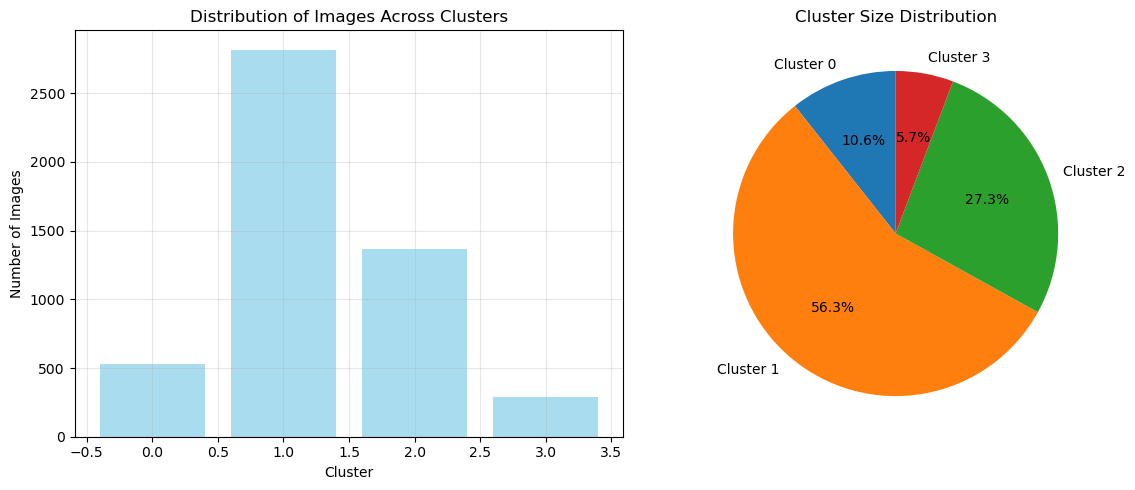

In [18]:
# Initialize clustering analyzer with CNN extractor
clustering_analyzer = ClusteringAnalyzer(cnn_extractor)

# Process the extracted features
features_scaled = clustering_analyzer.process_features(features)

# Find optimal number of clusters (optional)
k_range, inertias, optimal_k = clustering_analyzer.elbow_method()
print(f"\nOptimal number of clusters: {optimal_k}")

# Perform clustering with specific number of clusters
cluster_labels = clustering_analyzer.perform_clustering(n_clusters=optimal_k)

# Run complete evaluation phase
evaluation_results = clustering_analyzer.evaluation_phase(plot_distribution=True)

To expand the previous results, the clustering is executed using the optimal number of clusters adding and substracting 2 units.


Performing clustering with 2 clusters...

EVALUATION PHASE
Calculating evaluation metrics...

Clustering Evaluation Metrics:
Silhouette Score: 0.3914
Davies-Bouldin Index: 1.0200
Calinski-Harabasz Index: nan

Clustering Summary:
Number of clusters: 2

Cluster sizes:
Cluster 0: 1481 images
Cluster 1: 3519 images


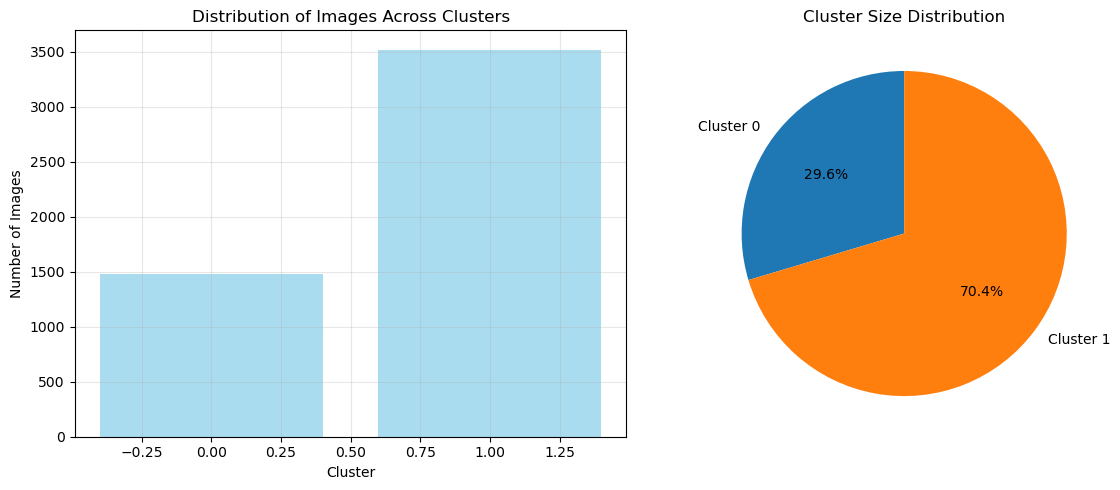


Performing clustering with 3 clusters...

EVALUATION PHASE
Calculating evaluation metrics...

Clustering Evaluation Metrics:
Silhouette Score: 0.4239
Davies-Bouldin Index: 0.9150
Calinski-Harabasz Index: nan

Clustering Summary:
Number of clusters: 3

Cluster sizes:
Cluster 0: 3297 images
Cluster 1: 1385 images
Cluster 2: 318 images


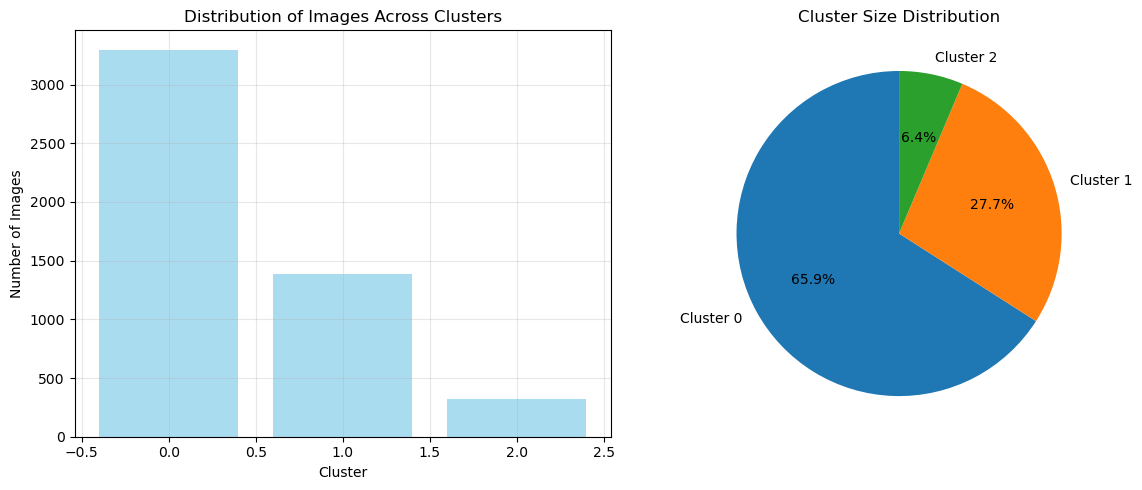


Performing clustering with 4 clusters...

EVALUATION PHASE
Calculating evaluation metrics...

Clustering Evaluation Metrics:
Silhouette Score: 0.4131
Davies-Bouldin Index: 0.9473
Calinski-Harabasz Index: nan

Clustering Summary:
Number of clusters: 4

Cluster sizes:
Cluster 0: 532 images
Cluster 1: 2816 images
Cluster 2: 1365 images
Cluster 3: 287 images


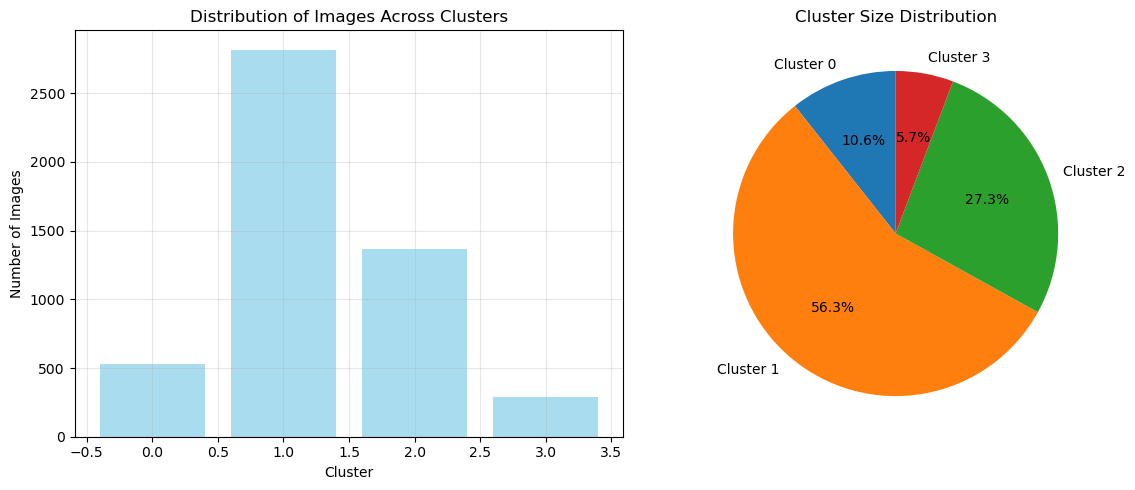


Performing clustering with 5 clusters...

EVALUATION PHASE
Calculating evaluation metrics...

Clustering Evaluation Metrics:
Silhouette Score: 0.3868
Davies-Bouldin Index: 0.8956
Calinski-Harabasz Index: nan

Clustering Summary:
Number of clusters: 5

Cluster sizes:
Cluster 0: 1470 images
Cluster 1: 2028 images
Cluster 2: 801 images
Cluster 3: 256 images
Cluster 4: 445 images


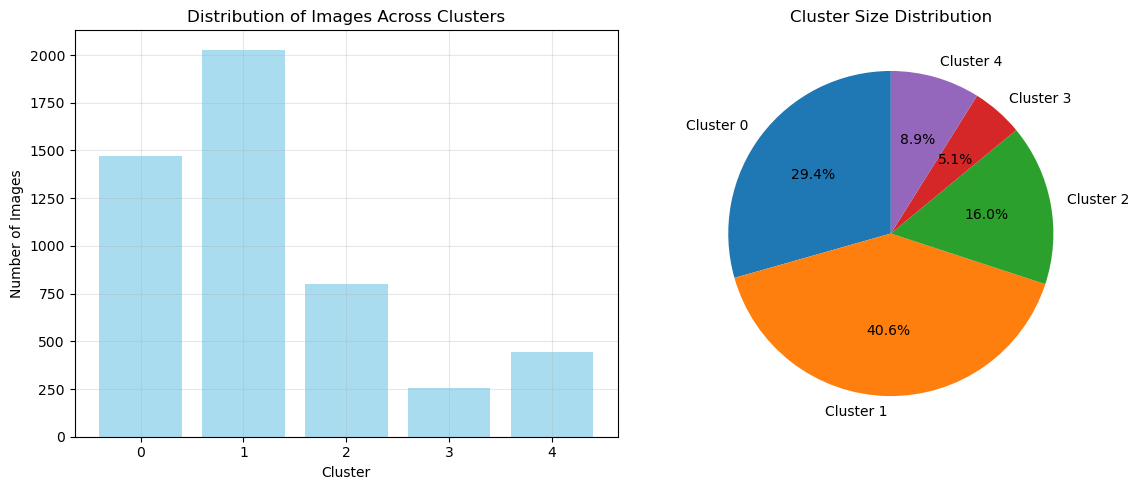


Performing clustering with 6 clusters...

EVALUATION PHASE
Calculating evaluation metrics...

Clustering Evaluation Metrics:
Silhouette Score: 0.3778
Davies-Bouldin Index: 0.8960
Calinski-Harabasz Index: nan

Clustering Summary:
Number of clusters: 6

Cluster sizes:
Cluster 0: 1443 images
Cluster 1: 495 images
Cluster 2: 779 images
Cluster 3: 124 images
Cluster 4: 1741 images
Cluster 5: 418 images


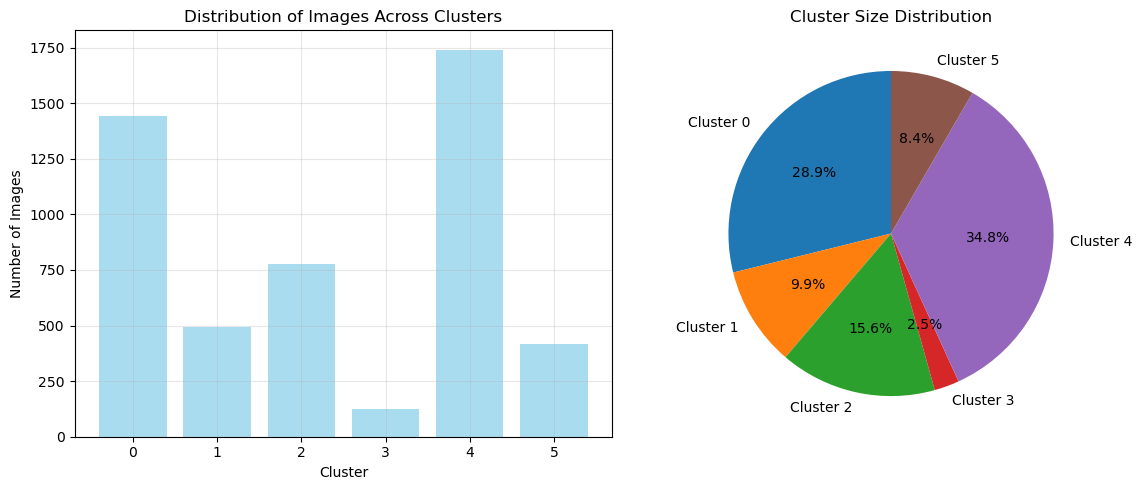

In [23]:
# Perform clustering using the optimal number of clusters with +-2 of range
for i in range(optimal_k - 2, optimal_k + 3):
    print(f"\nPerforming clustering with {i} clusters...")
    _ = clustering_analyzer.perform_clustering(n_clusters=i)
    _ = clustering_analyzer.evaluation_phase(plot_distribution=True)

To uderstand better the previous results, the clusters from the optimal number of clusters are plotted.

Performing t-SNE dimensionality reduction...
Note: Could not plot cluster centers in t-SNE space


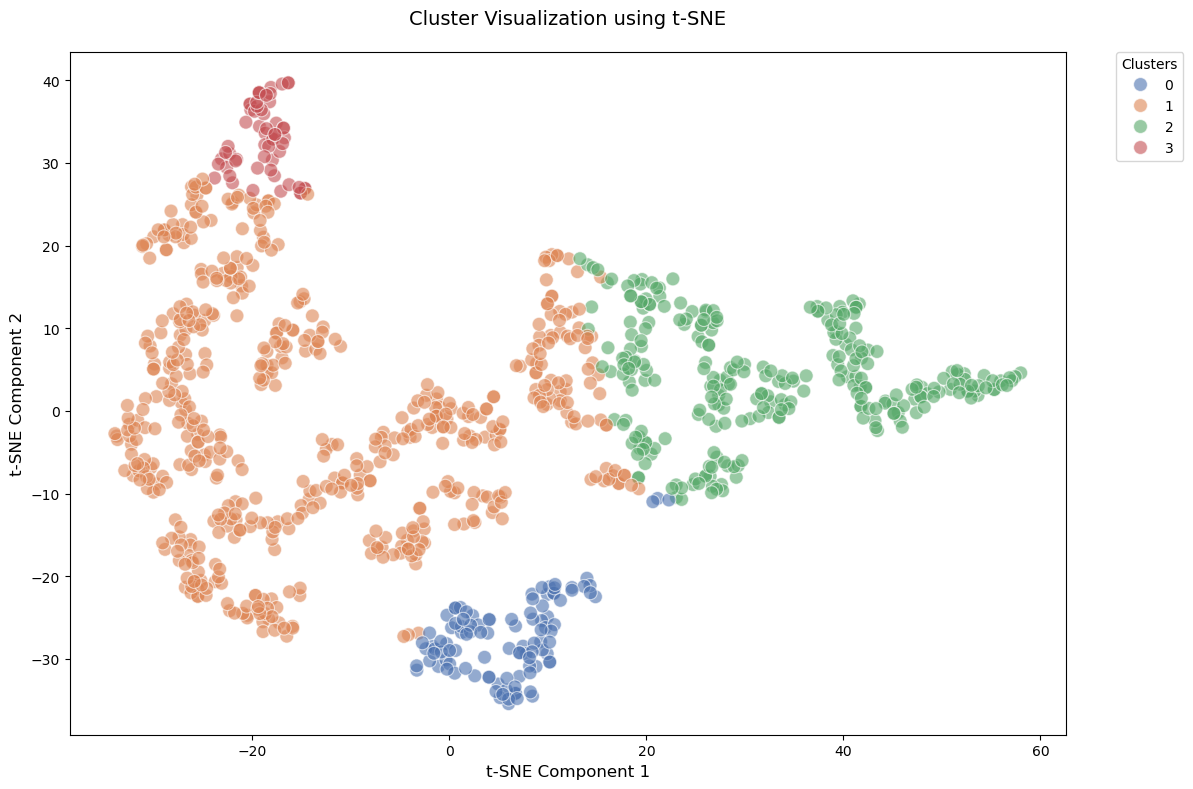

In [19]:
_ = clustering_analyzer.visualize_clusters_tsne(
        perplexity=30,  # Adjust based on your dataset size
        sample_size=1000  # Optional: use fewer samples for faster visualization
)

### Model 2 - Image + Latent Fusion for Clustering

Similar to the evaluation of the first model, the elbow method is used to get the best number of clusters and then cluster the results.

CLUSTERING PHASE
Finding optimal number of clusters...


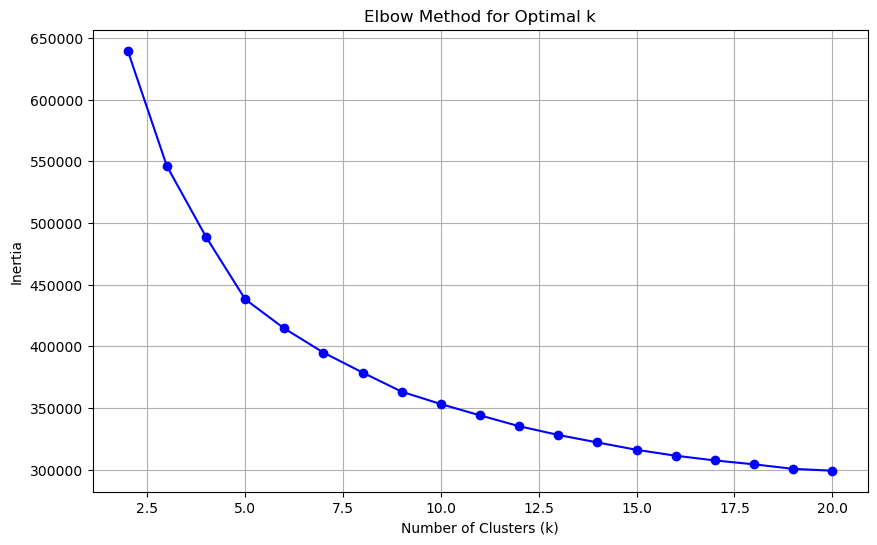


Optimal number of clusters: 4

EVALUATION PHASE
Calculating evaluation metrics...

Clustering Evaluation Metrics:
Silhouette Score: 0.2422
Davies-Bouldin Index: 1.4101
Calinski-Harabasz Index: 1214.3934

Clustering Summary:
Number of clusters: 4

Cluster sizes:
Cluster 0: 2809 images
Cluster 1: 285 images
Cluster 2: 541 images
Cluster 3: 1365 images


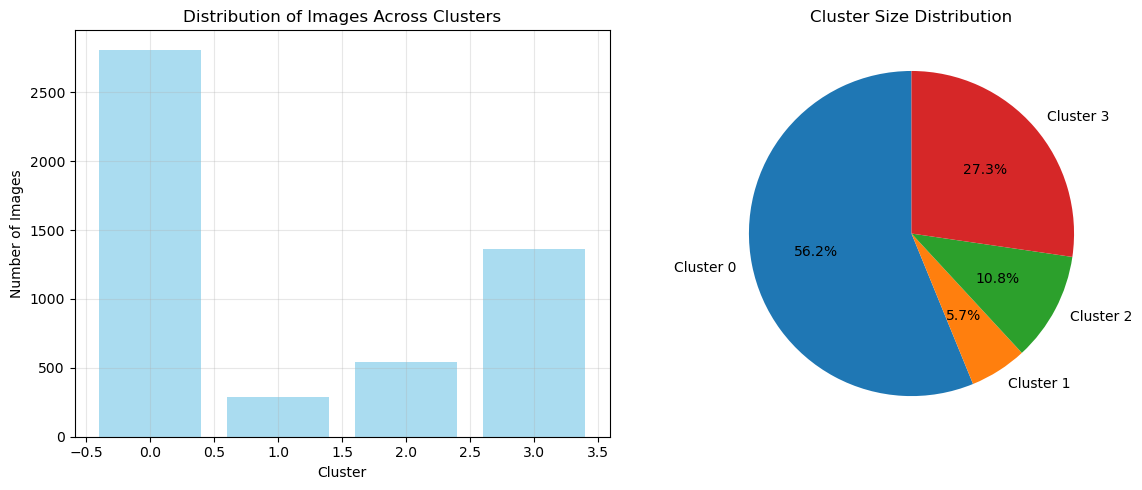

In [18]:
# Initialize clustering analyzer
clustering_analyzer_model2 = ClusteringAnalyzer(cnn_extractor)
features_scaled = clustering_analyzer_model2.process_features(fused_features)

# Find optimal number of clusters (optional)
k_range, inertias, optimal_k = clustering_analyzer_model2.elbow_method()
print(f"\nOptimal number of clusters: {optimal_k}")

# Perform clustering with sampling
cluster_labels = clustering_analyzer_model2.perform_clustering(
    n_clusters=optimal_k,
    sample_size=5000  # Sample size for large datasets
)

# Evaluate results
evaluation_results = clustering_analyzer_model2.evaluation_phase(plot_distribution=True)

Now, it is necessary to expand the evaluation to get a wider perspective of the model.


Performing clustering with 2 clusters...

EVALUATION PHASE
Calculating evaluation metrics...

Clustering Evaluation Metrics:
Silhouette Score: 0.2597
Davies-Bouldin Index: 1.4721
Calinski-Harabasz Index: 1604.8868

Clustering Summary:
Number of clusters: 2

Cluster sizes:
Cluster 0: 1485 images
Cluster 1: 3515 images


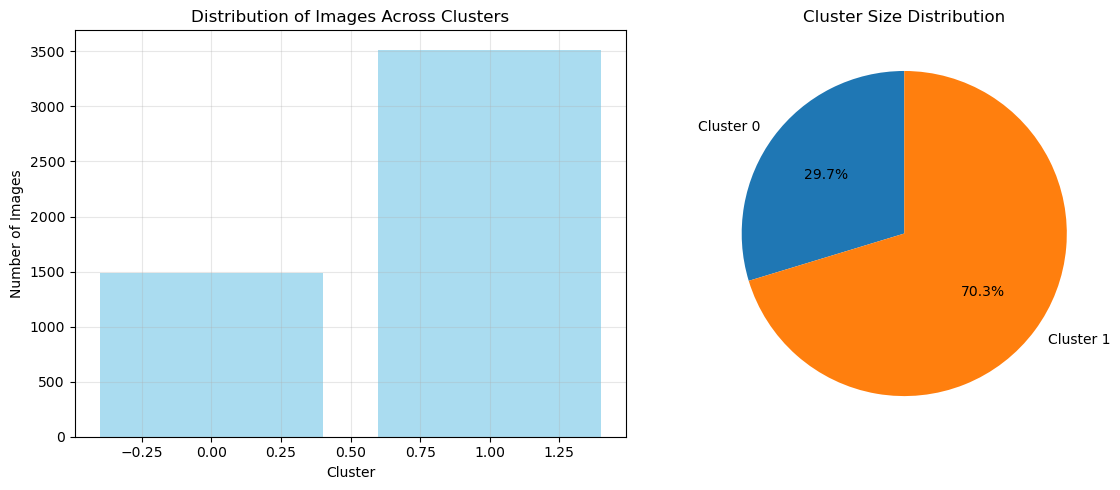


Performing clustering with 3 clusters...

EVALUATION PHASE
Calculating evaluation metrics...

Clustering Evaluation Metrics:
Silhouette Score: 0.2767
Davies-Bouldin Index: 1.3261
Calinski-Harabasz Index: 1368.1387

Clustering Summary:
Number of clusters: 3

Cluster sizes:
Cluster 0: 1390 images
Cluster 1: 3291 images
Cluster 2: 319 images


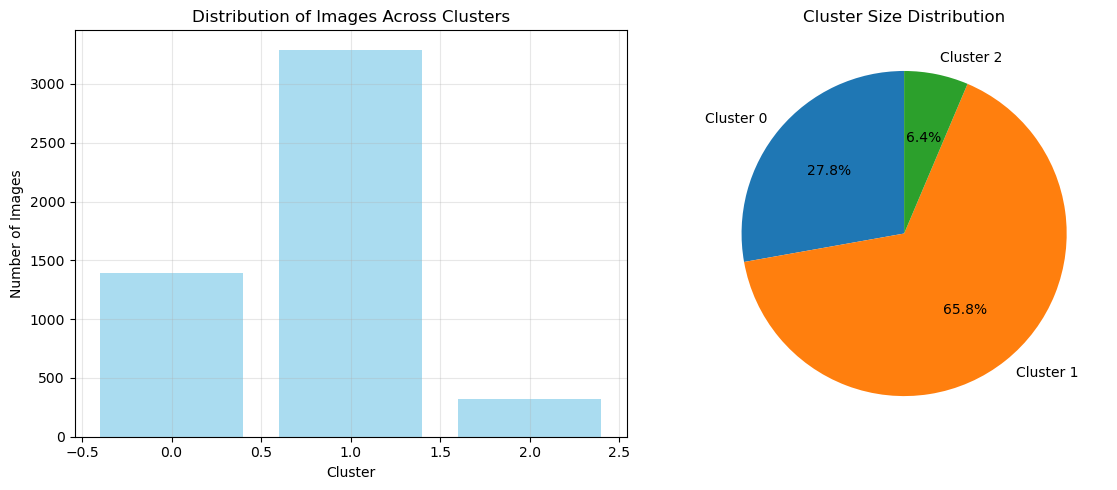


Performing clustering with 4 clusters...

EVALUATION PHASE
Calculating evaluation metrics...

Clustering Evaluation Metrics:
Silhouette Score: 0.2422
Davies-Bouldin Index: 1.4101
Calinski-Harabasz Index: 1214.3934

Clustering Summary:
Number of clusters: 4

Cluster sizes:
Cluster 0: 2809 images
Cluster 1: 285 images
Cluster 2: 541 images
Cluster 3: 1365 images


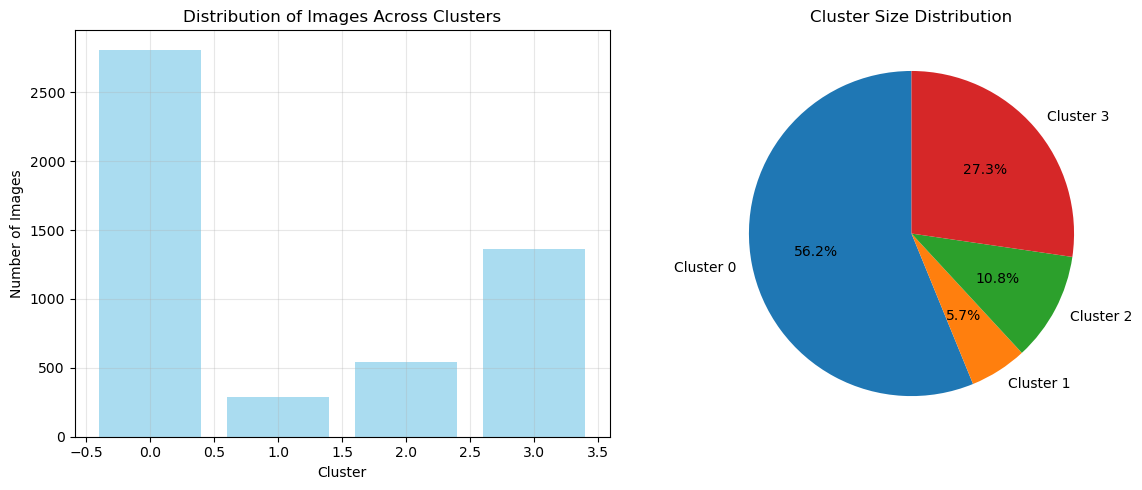


Performing clustering with 5 clusters...

EVALUATION PHASE
Calculating evaluation metrics...

Clustering Evaluation Metrics:
Silhouette Score: 0.2006
Davies-Bouldin Index: 1.5430
Calinski-Harabasz Index: 1159.7683

Clustering Summary:
Number of clusters: 5

Cluster sizes:
Cluster 0: 1468 images
Cluster 1: 449 images
Cluster 2: 800 images
Cluster 3: 255 images
Cluster 4: 2028 images


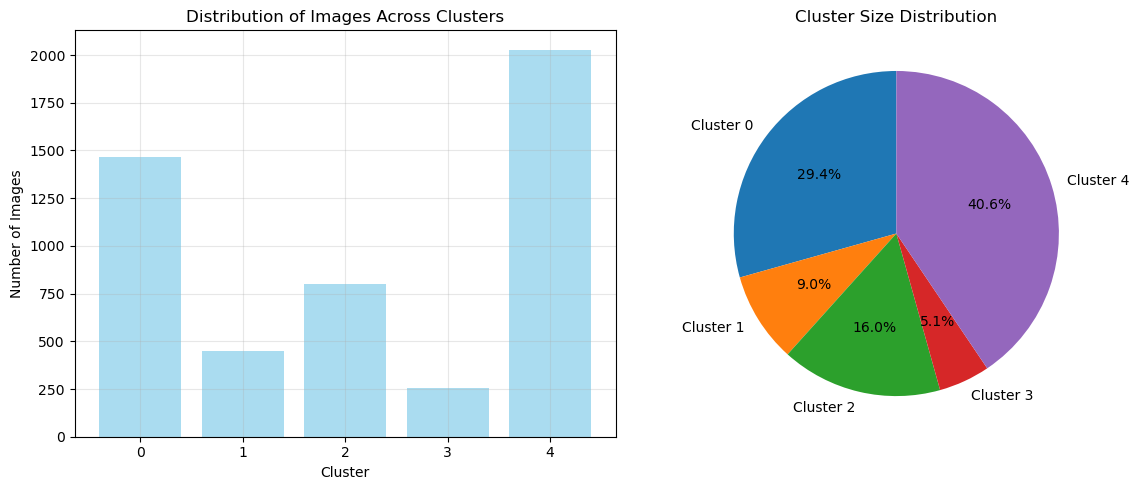


Performing clustering with 6 clusters...

EVALUATION PHASE
Calculating evaluation metrics...

Clustering Evaluation Metrics:
Silhouette Score: 0.1784
Davies-Bouldin Index: 1.5569
Calinski-Harabasz Index: 1037.6156

Clustering Summary:
Number of clusters: 6

Cluster sizes:
Cluster 0: 419 images
Cluster 1: 501 images
Cluster 2: 797 images
Cluster 3: 1432 images
Cluster 4: 125 images
Cluster 5: 1726 images


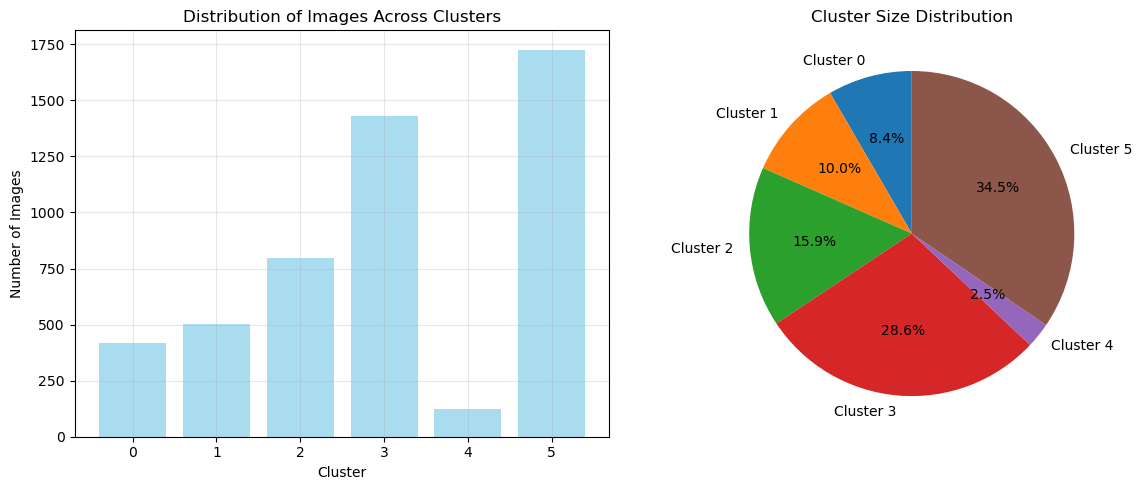

In [19]:
# Perform clustering using the optimal number of clusters with +-2 of range
for i in range(optimal_k - 2, optimal_k + 3):
    print(f"\nPerforming clustering with {i} clusters...")
    _ = clustering_analyzer_model2.perform_clustering(n_clusters=i)
    _ = clustering_analyzer_model2.evaluation_phase(plot_distribution=True)

Finally, the plot with the best number of clusters is shown to evaluate it.

Performing t-SNE dimensionality reduction...
Note: Could not plot cluster centers in t-SNE space


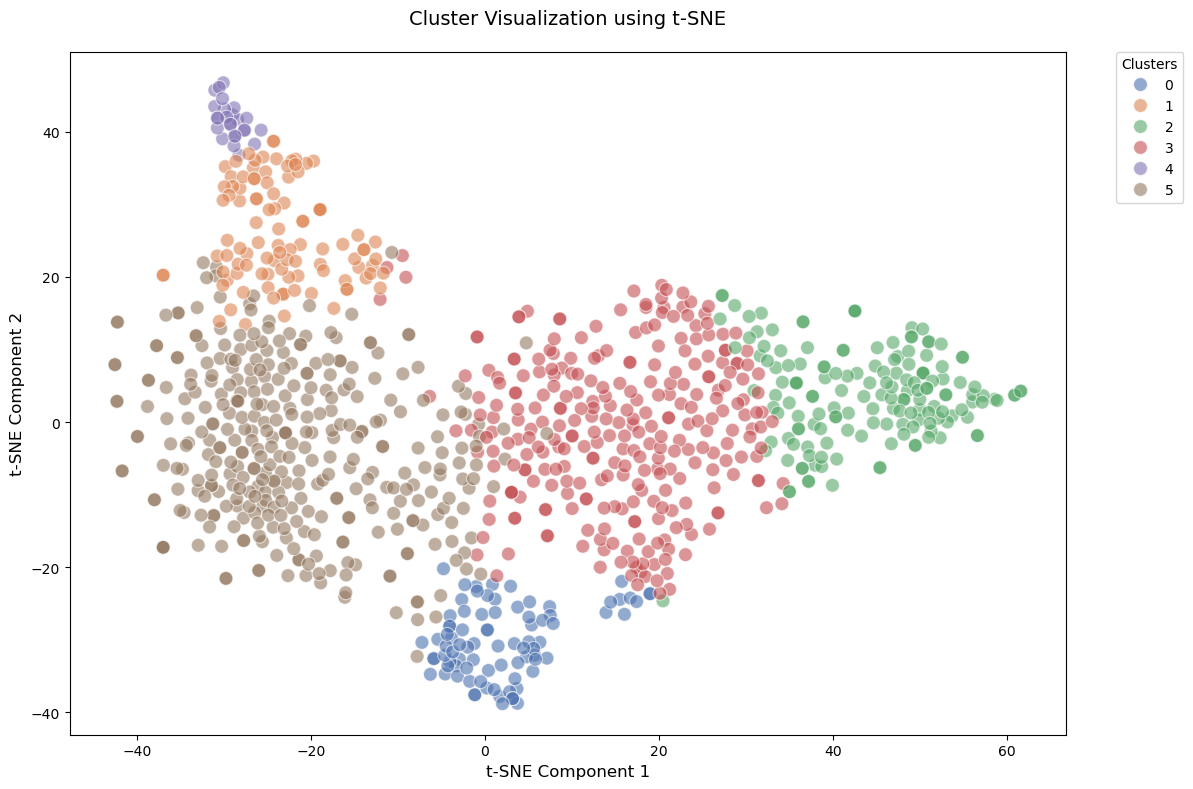

In [20]:
_ = clustering_analyzer_model2.visualize_clusters_tsne(
        perplexity=30,  # Adjust based on your dataset size
        sample_size=1000  # Optional: use fewer samples for faster visualization
)